**Исследование: "Эффективность новой иммунотерапии (Drug_A) vs стандартная химиотерапия (Drug_B) при метастатическом раке легкого"**

Первичная конечная точка:

Общая выживаемость (Overall Survival, OS)

Вторичные конечные точки:

Время до прогрессирования (Progression-Free Survival, PFS)

Композитная точка: PFS или смерть (анализ с помощью Win Ratio)

Период наблюдения: 24 месяца
Иерархия для Win Ratio:

Общая выживаемость (смерть)

Время до прогрессирования заболевания

In [50]:
if (!require(survival)) install.packages("survival")
if (!require(survminer)) install.packages("survminer")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(WR)) install.packages("WR")  # Альтернативный пакет

library(survival)
library(survminer)
library(ggplot2)
library(WR)

In [51]:
# Устанавливаем необходимые пакеты
if (!require(survival)) install.packages("survival")
if (!require(survminer)) install.packages("survminer")
if (!require(ggplot2)) install.packages("ggplot2")

library(survival)
library(survminer)
library(ggplot2)

# 1. СОЗДАНИЕ ДАННЫХ ДЛЯ ОНКОЛОГИЧЕСКОГО ИССЛЕДОВАНИЯ

set.seed(0)
n_patients <- 100

# Создаем кластеры пациентов с одинаковыми исходами для генерации ничьих
data <- data.frame(
  patient_id = 1:n_patients,
  treatment = rep(c("Drug_A", "Drug_B"), each = n_patients/2),
  
  # Drug_A группа - лучшие результаты
  time_to_progression = round(c(
    pmin(rexp(50, rate = 1/10), 24),  # Лучшее время до прогрессирования
    pmin(rexp(50, rate = 1/6), 24)    # Худшее время до прогрессирования
  )),
  
  # Drug_A группа - лучшая выживаемость
  time_to_death = round(c(
    pmin(rexp(50, rate = 1/15), 24),  # Лучшая выживаемость
    pmin(rexp(50, rate = 1/10), 24)   # Худшая выживаемость
  )
))

# Создаем статусы событий (1 = событие произошло, 0 = цензурировано)
data$progression_status <- ifelse(data$time_to_progression < 24, 1, 0)
data$death_status <- ifelse(data$time_to_death < 24, 1, 0)
# Просмотр первых строк данных
data

patient_id,treatment,time_to_progression,time_to_death,progression_status,death_status
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Drug_A,2,8,1,1
2,Drug_A,1,7,1,1
3,Drug_A,1,6,1,1
4,Drug_A,4,19,1,1
5,Drug_A,24,24,0,0
6,Drug_A,12,3,1,1
7,Drug_A,5,24,1,0
8,Drug_A,10,8,1,1
9,Drug_A,1,11,1,1


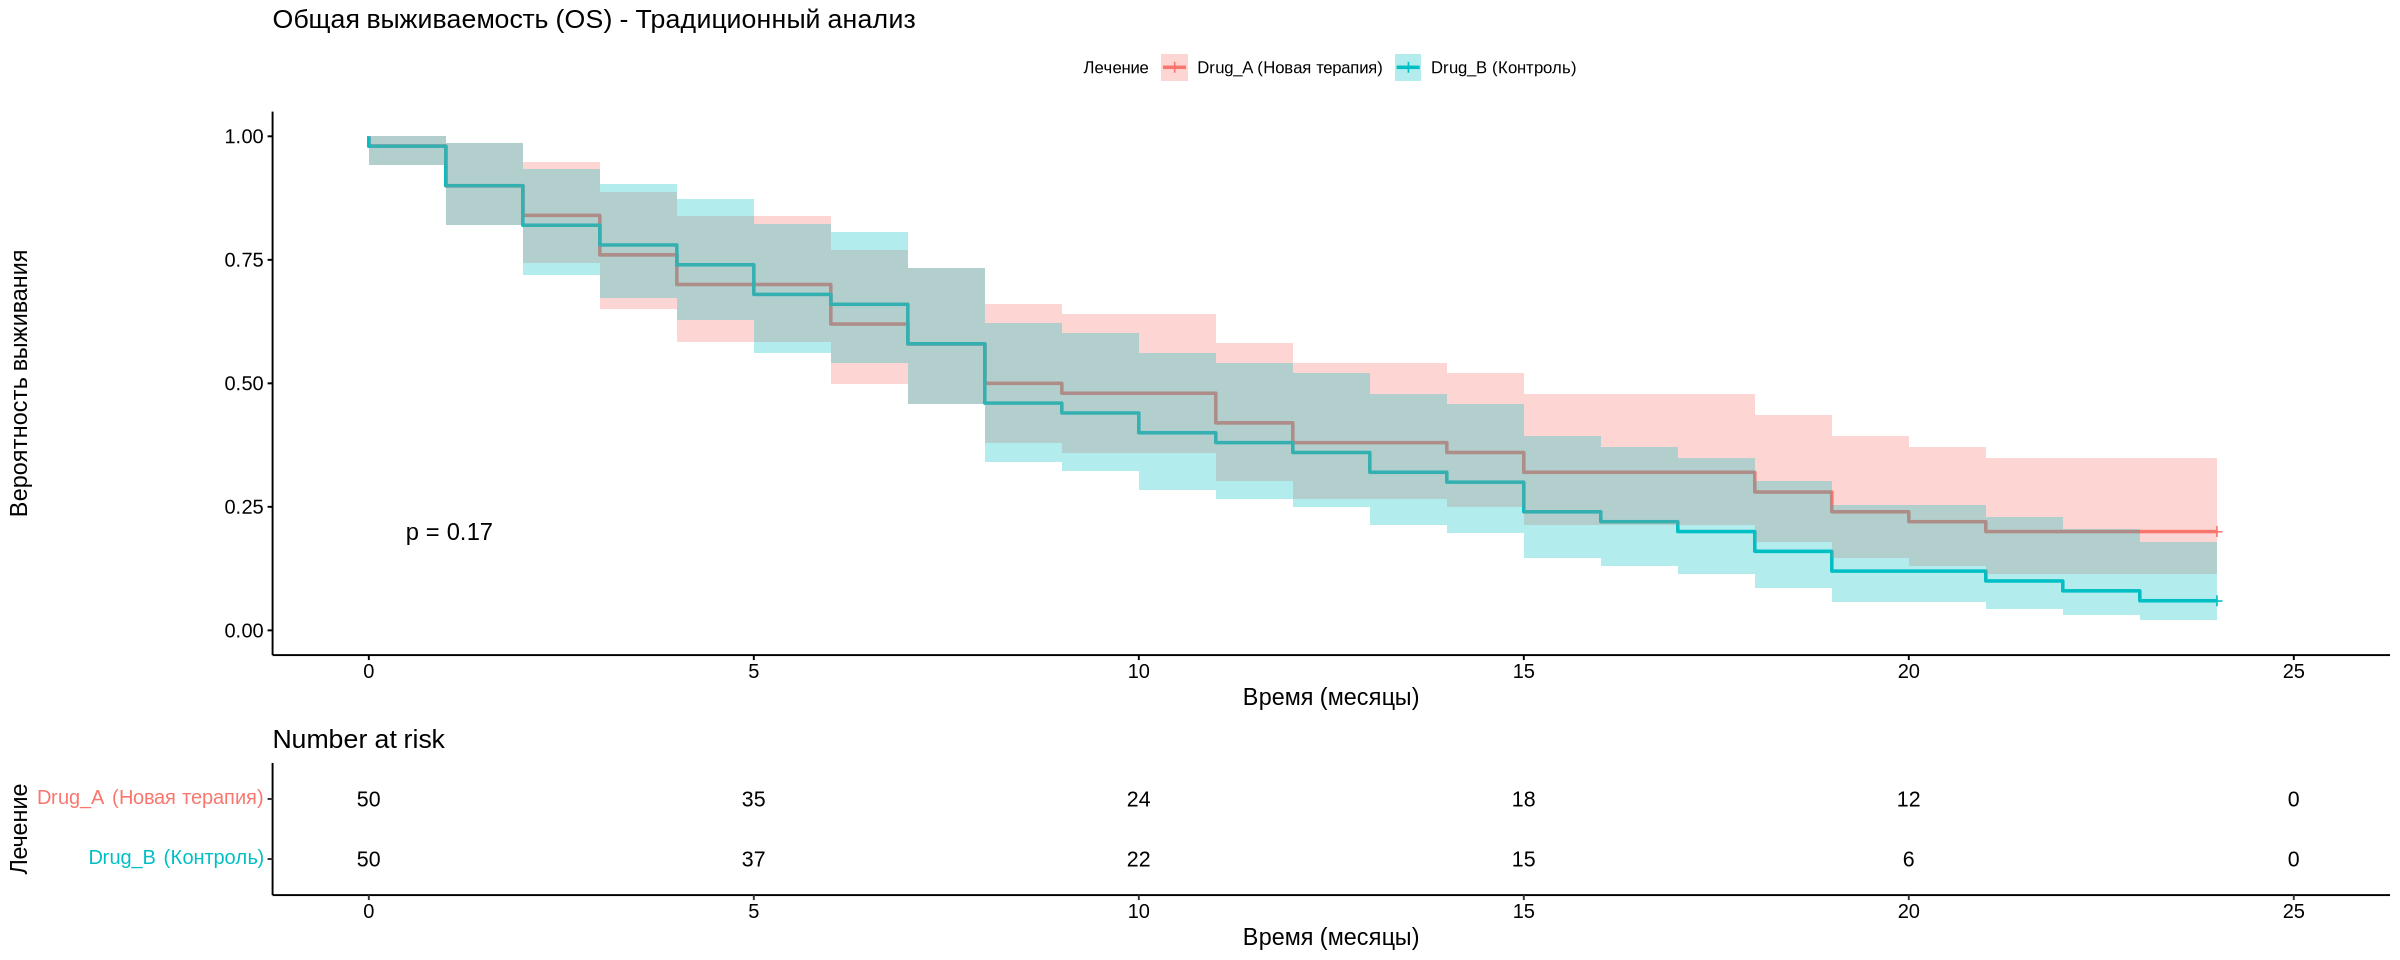

In [52]:
# 2. ТРАДИЦИОННЫЙ АНАЛИЗ ДОЖИТИЯ

# Анализ общей выживаемости (Overall Survival)
os_fit <- survfit(Surv(time_to_death, death_status) ~ treatment, data = data)

# Кривые Каплана-Мейера для OS
os_plot <- ggsurvplot(os_fit, 
           data = data,
           pval = TRUE,
           conf.int = TRUE,
           risk.table = TRUE,
           title = "Общая выживаемость (OS) - Традиционный анализ",
           xlab = "Время (месяцы)",
           ylab = "Вероятность выживания",
           legend.title = "Лечение",
           legend.labs = c("Drug_A (Новая терапия)", "Drug_B (Контроль)"),
           theme = theme_bw())

print(os_plot)

In [53]:
# Cox regression для HR общей выживаемости
os_cox <- coxph(Surv(time_to_death, death_status) ~ treatment, data = data)
os_summary <- summary(os_cox)

cat("=== АНАЛИЗ ОБЩЕЙ ВЫЖИВАЕМОСТИ (OS) ===\n")
cat("Hazard Ratio (HR):", round(exp(os_cox$coefficients), 3), "\n")
cat("95% ДИ:", round(exp(confint(os_cox)), 3), "\n")
cat("P-значение:", round(os_summary$coefficients[5], 4), "\n\n")

os_summary

=== АНАЛИЗ ОБЩЕЙ ВЫЖИВАЕМОСТИ (OS) ===
Hazard Ratio (HR): 1.341 
95% ДИ: 0.877 2.049 
P-значение: 0.1756 



Call:
coxph(formula = Surv(time_to_death, death_status) ~ treatment, 
    data = data)

  n= 100, number of events= 87 

                  coef exp(coef) se(coef)     z Pr(>|z|)
treatmentDrug_B 0.2932    1.3407   0.2164 1.354    0.176

                exp(coef) exp(-coef) lower .95 upper .95
treatmentDrug_B     1.341     0.7459    0.8772     2.049

Concordance= 0.519  (se = 0.031 )
Likelihood ratio test= 1.84  on 1 df,   p=0.2
Wald test            = 1.83  on 1 df,   p=0.2
Score (logrank) test = 1.85  on 1 df,   p=0.2


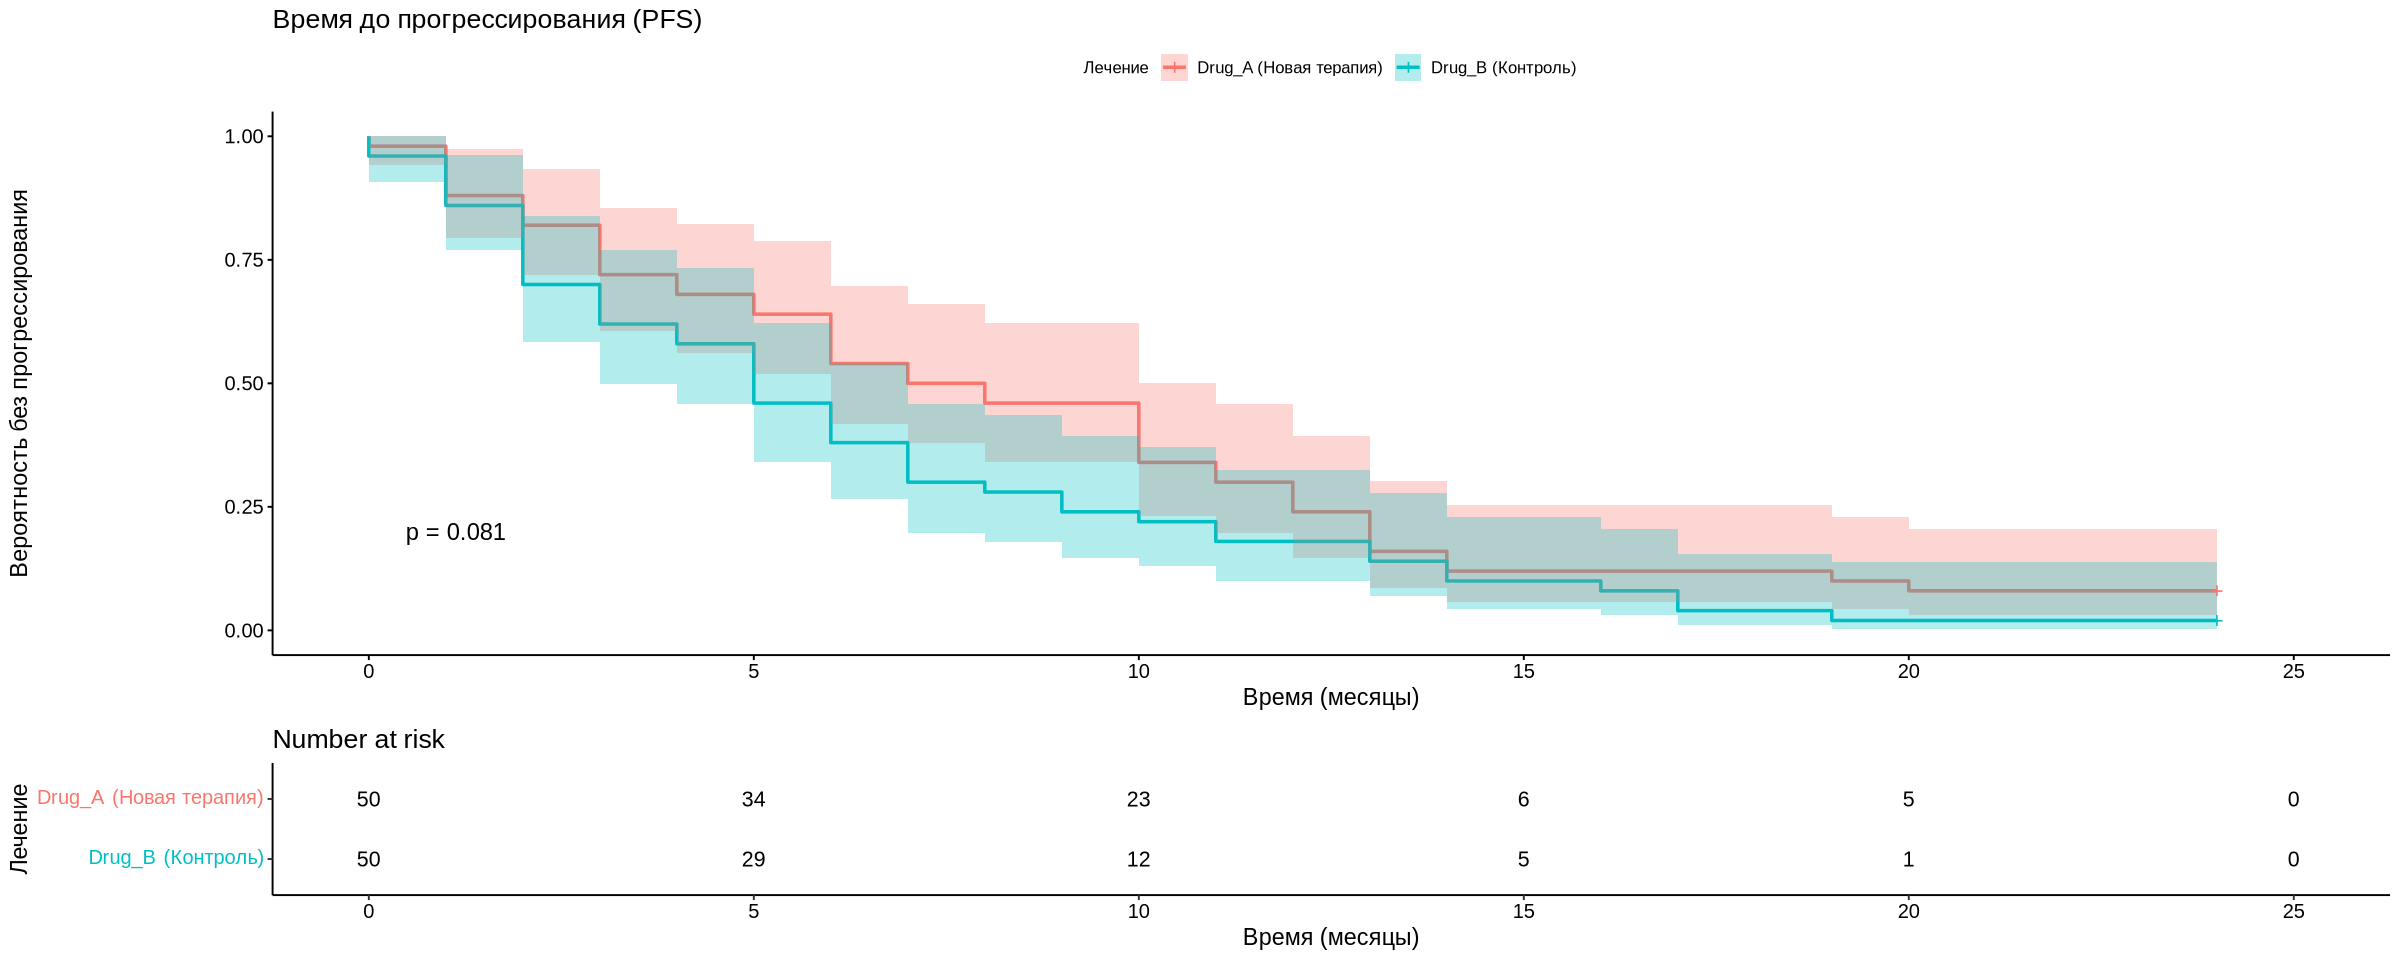

In [54]:

# Анализ времени до прогрессирования (PFS)
pfs_fit <- survfit(Surv(time_to_progression, progression_status) ~ treatment, data = data)

# Кривые Каплана-Мейера для PFS
pfs_plot <- ggsurvplot(pfs_fit, 
           data = data,
           pval = TRUE,
           conf.int = TRUE,
           risk.table = TRUE,
           title = "Время до прогрессирования (PFS)",
           xlab = "Время (месяцы)",
           ylab = "Вероятность без прогрессирования",
           legend.title = "Лечение",
           legend.labs = c("Drug_A (Новая терапия)", "Drug_B (Контроль)"))

print(pfs_plot)

In [55]:
pfs_cox <- coxph(Surv(time_to_progression, progression_status) ~ treatment, data = data)
pfs_summary <- summary(pfs_cox)

cat("=== АНАЛИЗ ВРЕМЕНИ ДО ПРОГРЕССИРОВАНИЯ (PFS) ===\n")
cat("Hazard Ratio (HR):", round(exp(pfs_cox$coefficients), 3), "\n")
cat("95% ДИ:", round(exp(confint(pfs_cox)), 3), "\n")
cat("P-значение:", round(pfs_summary$coefficients[5], 4), "\n\n")

=== АНАЛИЗ ВРЕМЕНИ ДО ПРОГРЕССИРОВАНИЯ (PFS) ===
Hazard Ratio (HR): 1.42 
95% ДИ: 0.947 2.13 
P-значение: 0.0902 



In [56]:
# 1. FIRST LET'S ANALYZE EACH ENDPOINT SEPARATELY
# Function to compare patients for each specific endpoint
compare_endpoint <- function(p1, p2, endpoint) {
  if (endpoint == "death") {
    # Compare mortality
    if (p1$death_status == 0 & p2$death_status == 1) return("win")
    else if (p1$death_status == 1 & p2$death_status == 0) return("loss")
    else if (p1$death_status == 1 & p2$death_status == 1) {
      if (p1$time_to_death > p2$time_to_death) return("win")
      if (p1$time_to_death < p2$time_to_death) return("loss")
    }
  } else if (endpoint == "progression") {
    # Compare progression
    if (p1$progression_status == 0 & p2$progression_status == 1) return("win")
    else if (p1$progression_status == 1 & p2$progression_status == 0) return("loss")
    else if (p1$progression_status == 1 & p2$progression_status == 1) {
      if (p1$time_to_progression > p2$time_to_progression) return("win")
      if (p1$time_to_progression < p2$time_to_progression) return("loss")
    }
  }
  return("tie")
}

# Analyze each endpoint separately
endpoint_results <- list()

for (endpoint in c("death", "progression")) {
  wins <- 0
  losses <- 0
  ties <- 0
  
  for (i in 1:nrow(drug_a)) {
    for (j in 1:nrow(drug_b)) {
      result <- compare_endpoint(drug_a[i, ], drug_b[j, ], endpoint)
      if (result == "win") wins <- wins + 1
      if (result == "loss") losses <- losses + 1
      if (result == "tie") ties <- ties + 1
    }
  }
  
  endpoint_results[[endpoint]] <- list(
    wins = wins,
    losses = losses,
    ties = ties,
    total = wins + losses + ties,
    ratio = ifelse(losses > 0, wins/losses, NA)
  )
}

# 2. CREATE HEAD-TO-HEAD BARPLOTS FOR EACH ENDPOINT

# Plot 1: Individual endpoint comparisons
endpoint_plot_data <- data.frame(
  Endpoint = rep(c("Overall Survival", "Progression-Free Survival"), each = 3),
  Outcome = rep(c("Drug_A Wins", "Ties", "Drug_B Wins"), 2),
  Count = c(endpoint_results$death$wins, endpoint_results$death$ties, endpoint_results$death$losses,
           endpoint_results$progression$wins, endpoint_results$progression$ties, endpoint_results$progression$losses),
  Percentage = c(
    round(c(endpoint_results$death$wins, endpoint_results$death$ties, endpoint_results$death$losses) / 
           endpoint_results$death$total * 100, 1),
    round(c(endpoint_results$progression$wins, endpoint_results$progression$ties, endpoint_results$progression$losses) / 
           endpoint_results$progression$total * 100, 1)
  )
)

# Head-to-head barplot for each endpoint
ggplot(endpoint_plot_data, aes(x = Outcome, y = Count, fill = Outcome)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_text(aes(label = paste0(Count, "\n(", Percentage, "%)")), 
            vjust = -0.3, size = 3.5) +
  facet_wrap(~ Endpoint, scales = "free_x") +
  scale_fill_manual(values = c("Drug_A Wins" = "#2E8B57", 
                              "Ties" = "#FFD700", 
                              "Drug_B Wins" = "#CD5C5C")) +
  labs(title = "Head-to-Head Comparisons by Individual Endpoint",
       subtitle = "Pairwise analysis of each component separately",
       x = "Comparison Outcome", 
       y = "Number of Patient Pairs") +
  theme_minimal() +
  theme(plot.title = element_text(size = 14, face = "bold"),
        strip.text = element_text(size = 11, face = "bold"),
        axis.text.x = element_text(angle = 45, hjust = 1))

# 3. MIRRORED PYRAMID PLOTS FOR EACH ENDPOINT

# Create pyramid data
pyramid_data <- data.frame(
  Endpoint = rep(c("Overall Survival", "Progression-Free Survival"), each = 2),
  Direction = rep(c("Drug_A Better", "Drug_B Better"), 2),
  Count = c(endpoint_results$death$wins, endpoint_results$death$losses,
           endpoint_results$progression$wins, endpoint_results$progression$losses),
  YPosition = c(1, -1, 2, -2)  # For positioning
)

# Pyramid plot for both endpoints
ggplot(pyramid_data, aes(x = Direction, y = ifelse(Direction == "Drug_A Better", Count, -Count), 
                        fill = Direction)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = Count), 
            vjust = ifelse(pyramid_data$Direction == "Drug_A Better", -0.5, 1.2),
            size = 4, fontface = "bold") +
  facet_wrap(~ Endpoint, ncol = 1) +
  scale_fill_manual(values = c("Drug_A Better" = "#2E8B57", 
                              "Drug_B Better" = "#CD5C5C")) +
  scale_y_continuous(labels = abs) +
  coord_flip() +
  labs(title = "Mirrored Pyramid Plot: Endpoint-Specific Comparisons",
       subtitle = "Showing decisive outcomes (excluding ties)",
       x = "Treatment Advantage", 
       y = "Number of Patient Pairs") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold"))

# 4. WIN RATIOS ACROSS HIERARCHY LEVELS

# Calculate win ratios for each level
hierarchy_data <- data.frame(
  Level = c("Level 1: Overall Survival", "Level 2: Progression-Free", "Composite: Win Ratio"),
  WinRatio = c(endpoint_results$death$wins/endpoint_results$death$losses,
              endpoint_results$progression$wins/endpoint_results$progression$losses,
              win_ratio),
  Wins = c(endpoint_results$death$wins, endpoint_results$progression$wins, wins),
  Losses = c(endpoint_results$death$losses, endpoint_results$progression$losses, losses),
  Ties = c(endpoint_results$death$ties, endpoint_results$progression$ties, ties)
)

# Win ratio comparison across hierarchy
ggplot(hierarchy_data, aes(x = Level, y = WinRatio, fill = Level)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0("WR = ", round(WinRatio, 2), 
                              "\n(W:", Wins, "/L:", Losses, ")")), 
            vjust = -0.3, size = 3.5) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red", size = 1) +
  scale_fill_manual(values = c("#1f77b4", "#ff7f0e", "#2ca02c")) +
  labs(title = "Win Ratio Across Hierarchy Levels",
       subtitle = "Comparison of individual endpoints vs composite Win Ratio",
       x = "Endpoint Level", 
       y = "Win Ratio") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold"),
        axis.text.x = element_text(angle = 45, hjust = 1))

# 5. DETAILED BREAKDOWN OF COMPOSITE WIN RATIO

# Analyze how each level contributes to final Win Ratio
composite_breakdown <- data.frame(
  DecisionLevel = c("Decided at OS Level", "Decided at PFS Level", "Ties (Excluded)"),
  Count = c(
    endpoint_results$death$wins + endpoint_results$death$losses,  # Decisions at OS level
    endpoint_results$progression$wins + endpoint_results$progression$losses - 
      (endpoint_results$death$wins + endpoint_results$death$losses),  # Decisions at PFS level
    ties  # Total ties in composite
  )
)

composite_breakdown$Percentage <- round(composite_breakdown$Count / total_pairs * 100, 1)

# Breakdown plot
ggplot(composite_breakdown, aes(x = DecisionLevel, y = Count, fill = DecisionLevel)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0(Count, "\n(", Percentage, "%)")), 
            vjust = -0.3, size = 4) +
  scale_fill_manual(values = c("#1f77b4", "#ff7f0e", "#FFD700")) +
  labs(title = "Composite Win Ratio Decision Breakdown",
       subtitle = "Where in the hierarchy were decisions made?",
       x = "Decision Level", 
       y = "Number of Pairs") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold"))

# 6. SIDE-BY-SIDE COMPARISON OF ALL METRICS

# Create comprehensive comparison dataset
comparison_metrics <- data.frame(
  Metric = c(rep("Overall Survival", 3), 
            rep("Progression-Free Survival", 3), 
            rep("Composite Win Ratio", 3)),
  Outcome = rep(c("Drug_A Wins", "Drug_B Wins", "Ties"), 3),
  Count = c(endpoint_results$death$wins, endpoint_results$death$losses, endpoint_results$death$ties,
           endpoint_results$progression$wins, endpoint_results$progression$losses, endpoint_results$progression$ties,
           wins, losses, ties),
  Percentage = round(c(
    endpoint_results$death$wins, endpoint_results$death$losses, endpoint_results$death$ties,
    endpoint_results$progression$wins, endpoint_results$progression$losses, endpoint_results$progression$ties,
    wins, losses, ties
  ) / rep(c(endpoint_results$death$total, endpoint_results$progression$total, total_pairs), each = 3) * 100, 1)
)

# Grouped barplot
ggplot(comparison_metrics, aes(x = Metric, y = Count, fill = Outcome)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  geom_text(aes(label = paste0(Count, "\n(", Percentage, "%)")), 
            position = position_dodge(width = 0.7), vjust = -0.3, size = 3) +
  scale_fill_manual(values = c("Drug_A Wins" = "#2E8B57", 
                              "Drug_B Wins" = "#CD5C5C", 
                              "Ties" = "#FFD700")) +
  labs(title = "Comprehensive Endpoint Comparison",
       subtitle = "Head-to-head results for all endpoints",
       x = "Endpoint Metric", 
       y = "Number of Patient Pairs",
       fill = "Outcome") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold"),
        axis.text.x = element_text(angle = 45, hjust = 1))

# 7. SUMMARY STATISTICS
cat("\n=== ENDPOINT-SPECIFIC WIN RATIO ANALYSIS ===\n")
cat("OVERALL SURVIVAL (Level 1):\n")
cat("  Drug_A Wins:", endpoint_results$death$wins, 
    "(", round(endpoint_results$death$wins/endpoint_results$death$total*100, 1), "%)\n")
cat("  Drug_B Wins:", endpoint_results$death$losses, 
    "(", round(endpoint_results$death$losses/endpoint_results$death$total*100, 1), "%)\n")
cat("  Ties:", endpoint_results$death$ties, 
    "(", round(endpoint_results$death$ties/endpoint_results$death$total*100, 1), "%)\n")
cat("  OS Win Ratio:", round(endpoint_results$death$wins/endpoint_results$death$losses, 3), "\n\n")

cat("PROGRESSION-FREE SURVIVAL (Level 2):\n")
cat("  Drug_A Wins:", endpoint_results$progression$wins, 
    "(", round(endpoint_results$progression$wins/endpoint_results$progression$total*100, 1), "%)\n")
cat("  Drug_B Wins:", endpoint_results$progression$losses, 
    "(", round(endpoint_results$progression$losses/endpoint_results$progression$total*100, 1), "%)\n")
cat("  Ties:", endpoint_results$progression$ties, 
    "(", round(endpoint_results$progression$ties/endpoint_results$progression$total*100, 1), "%)\n")
cat("  PFS Win Ratio:", round(endpoint_results$progression$wins/endpoint_results$progression$losses, 3), "\n\n")

cat("COMPOSITE WIN RATIO (Hierarchical):\n")
cat("  Drug_A Wins:", wins, "(", round(wins/total_pairs*100, 1), "%)\n")
cat("  Drug_B Wins:", losses, "(", round(losses/total_pairs*100, 1), "%)\n")
cat("  Ties:", ties, "(", round(ties/total_pairs*100, 1), "%)\n")
cat("  Composite Win Ratio:", round(win_ratio, 3), "\n")
cat("  Percentage decided at OS level:", 
    round((endpoint_results$death$wins + endpoint_results$death$losses)/total_pairs*100, 1), "%\n")
cat("  Percentage decided at PFS level:", 
    round((endpoint_results$progression$wins + endpoint_results$progression$losses - 
           endpoint_results$death$wins - endpoint_results$death$losses)/total_pairs*100, 1), "%\n")

ERROR: Error in eval(expr, envir, enclos): объект 'drug_a' не найден


In [ ]:
1512+985

[1] 2497

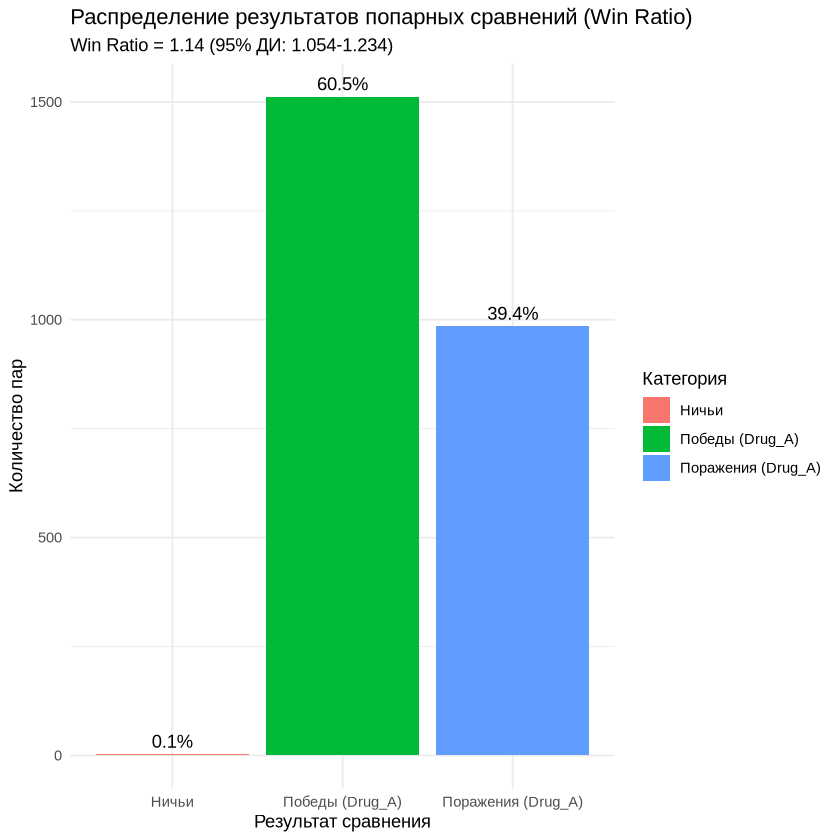

In [ ]:
# 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ WIN RATIO

# Создаем данные для визуализации
wr_results <- data.frame(
  Категория = c("Победы (Drug_A)", "Поражения (Drug_A)", "Ничьи"),
  Количество = c(wins, losses, ties),
  Процент = c(wins/total_pairs*100, losses/total_pairs*100, ties/total_pairs*100)
)

# График распределения результатов сравнений
ggplot(wr_results, aes(x = Категория, y = Количество, fill = Категория)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(round(Процент, 1), "%")), vjust = -0.5) +
  labs(title = "Распределение результатов попарных сравнений (Win Ratio)",
       subtitle = paste0("Win Ratio = ", round(win_ratio, 3), 
                        " (95% ДИ: ", round(ci_lower, 3), "-", round(ci_upper, 3), ")"),
       x = "Результат сравнения", 
       y = "Количество пар") +
  theme_minimal()

In [ ]:
# 5. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

results_summary <- data.frame(
  Метод = c("Традиционный анализ (OS HR)", 
           "Традиционный анализ (PFS HR)", 
           "Win Ratio"),
  Коэфф. = c(
    round(exp(os_cox$coefficients), 3),
    round(exp(pfs_cox$coefficients), 3),
    round(win_ratio, 3)
  ),
  Нижняя_граница_ДИ = c(
    round(exp(confint(os_cox))[1], 3),
    round(exp(confint(pfs_cox))[1], 3),
    round(ci_lower, 3)
  ),
  Верхняя_граница_ДИ = c(
    round(exp(confint(os_cox))[2], 3),
    round(exp(confint(pfs_cox))[2], 3),
    round(ci_upper, 3)
  ),
  p = c(
    round(os_summary$coefficients[5], 4),
    round(pfs_summary$coefficients[5], 4),
    round(p_value, 4)
  )
)

print(results_summary)

                         Метод Коэфф. Нижняя_граница_ДИ Верхняя_граница_ДИ
1  Традиционный анализ (OS HR)  1.305             0.856              1.990
2 Традиционный анализ (PFS HR)  1.421             0.949              2.127
3                    Win Ratio  1.140             1.054              1.234
       p
1 0.2161
2 0.0880
3 0.0010


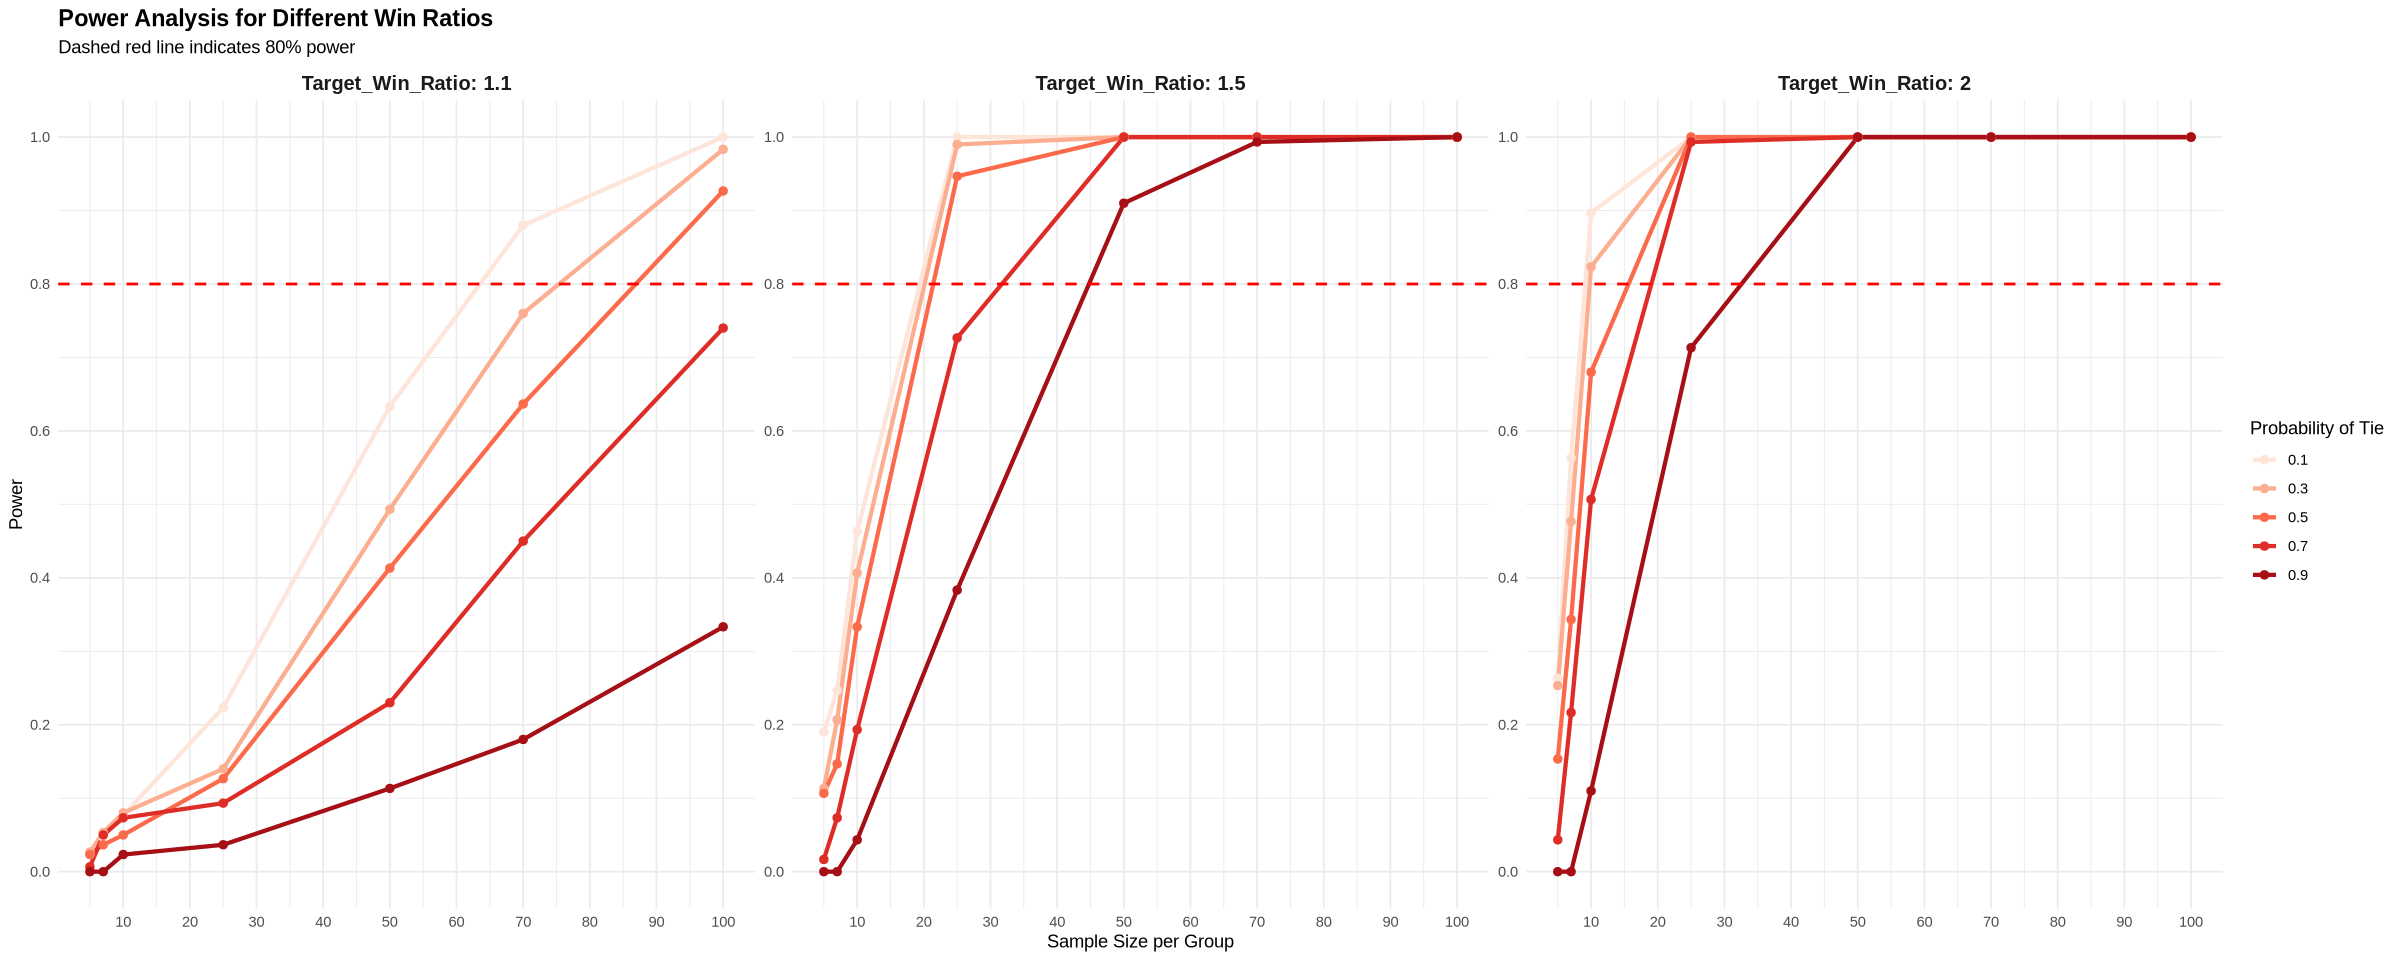

In [ ]:
library(tidyverse)

# Win Ratio simulation for different target win ratios
simulate_win_ratio_fixed <- function(n_per_group, p_tie, target_wr = 1.5, k = 1, n_simulations = 100) {
  # Calculate p_win needed to achieve target Win Ratio
  p_win_given_no_tie <- target_wr / (1 + target_wr)
  
  results <- data.frame(
    win_ratio = numeric(n_simulations),
    wins = numeric(n_simulations),
    losses = numeric(n_simulations),
    ties = numeric(n_simulations),
    significant = logical(n_simulations)
  )
  
  n_group1 <- n_per_group
  n_group2 <- round(n_per_group * k)
  total_pairs <- n_group1 * n_group2
  
  for (sim in 1:n_simulations) {
    n_ties <- rbinom(1, total_pairs, p_tie)
    n_decisions <- total_pairs - n_ties
    
    n_wins <- rbinom(1, n_decisions, p_win_given_no_tie)
    n_losses <- n_decisions - n_wins
    
    wr <- ifelse(n_losses > 0, n_wins / n_losses, NA)
    
    if (!is.na(wr) && n_losses > 0 && n_wins > 0) {
      se_log_wr <- sqrt(1/n_wins + 1/n_losses)
      z_score <- log(wr) / se_log_wr
      p_val <- 2 * (1 - pnorm(abs(z_score)))
      significant <- p_val < 0.05
    } else {
      significant <- FALSE
    }
    
    results[sim, ] <- c(wr, n_wins, n_losses, n_ties, significant)
  }
  
  return(results)
}

# Parameters
sample_sizes <- c(5, 7, 10, 25, 50, 70, 100)
tie_probs <- c(0.1, 0.3, 0.5, 0.7, 0.9)
target_wrs <- c(1.1, 1.5, 2.0)

# Run simulations
all_results <- data.frame()

for (target_wr in target_wrs) {
  for (n in sample_sizes) {
    for (p_tie in tie_probs) {
      results <- simulate_win_ratio_fixed(n, p_tie, target_wr, n_simulations = 300)
      
      summary_row <- data.frame(
        Target_Win_Ratio = target_wr,
        n_per_group = n,
        p_tie = p_tie,
        Power = mean(results$significant, na.rm = TRUE)
      )
      
      all_results <- rbind(all_results, summary_row)
    }
  }
}

# Power analysis plot with facets for different win ratios
p = ggplot(all_results, aes(x = n_per_group, y = Power, color = factor(p_tie), group = p_tie)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  geom_hline(yintercept = 0.8, linetype = "dashed", color = "red", size = 0.8) +
  facet_wrap(~ Target_Win_Ratio, labeller = label_both,  scales = "free") +
  scale_color_brewer(palette = "Reds", name = "Probability of Tie") +
  scale_x_continuous(breaks = seq(10, 100, 10)) +
  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
  labs(title = "Power Analysis for Different Win Ratios",
       subtitle = "Dashed red line indicates 80% power",
       x = "Sample Size per Group",
       y = "Power") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14),
        strip.text = element_text(face = "bold", size = 12))

options(repr.plot.width=20, repr.plot.height=8)
plot(p)

In [125]:
winRatioFromProb <- function(pC, OR, pTie, n){
  # 1) pT from the odds ratio
  pT <- OR * pC / (1 - pC + OR * pC)
  
  # 2) Pair-wise probabilities
  pWin  <- (1 - pT) * pC
  pLoss <-  pT       * (1 - pC)
  pTie_model <- pT * pC + (1 - pT) * (1 - pC)
  
  if(abs(pTie - pTie_model) > 1e-3)
    warning("pTie is inconsistent with pC and OR (difference = ",
            round(pTie - pTie_model, 4), ").")
  
  # 3) Win ratio
  WR <- pWin / pLoss
  
  # 4) Standard error and 95% CI
  Wexp <- n^2 * pWin
  Lexp <- n^2 * pLoss
  SE   <- sqrt(1 / Wexp + 1 / Lexp)
  CI   <- exp( log(WR) + c(-1, 1) * 1.96 * SE )
  
  list( pT = pT,
        Prob = c(pWin = pWin, pLoss = pLoss, pTie = pTie_model),
        WR   = WR,
        CI95 = CI,
        SE_logWR = SE )
}

## ---------------- EXAMPLE ----------------
## Control event rate  = 25 %
## Target odds ratio   = 0.70
## Tie probability     = 55 %    (made-up, but compatible)
## 400 patients per arm
res <- winRatioFromProb(pC  = 0.25,
                        OR  = 1.2,
                        pTie= 0.,
                        n   = 1000)

print(res)

Warning message in winRatioFromProb(pC = 0.25, OR = 1.2, pTie = 0, n = 1000):
“pTie is inconsistent with pC and OR (difference = -0.6071).”


$pT
[1] 0.2857143

$Prob
     pWin     pLoss      pTie 
0.1785714 0.2142857 0.6071429 

$WR
[1] 0.8333333

$CI95
[1] 0.8281163 0.8385833

$SE_logWR
[1] 0.003204164



### 1) Treatment Probability $p_T$ from Odds Ratio $OR$ and Control Probability $p_C$:

$$
p_{T} = \frac{OR \times p_{C}}{1 - p_{C} + OR \times p_{C}}
$$

***

### 2) Pairwise Probabilities of Win, Loss and Tie

$$
p_{\text{Win}} = (1 - p_{T}) \times p_{C}
$$

$$
p_{\text{Loss}} = p_{T} \times (1 - p_{C})
$$

$$
p_{\text{Tie (model)}} = p_{T} \times p_{C} + (1 - p_{T}) \times (1 - p_{C})
$$

***

### 3) Win Ratio $WR$:

$$
WR = \frac{p_{\text{Win}}}{p_{\text{Loss}}}
$$

***

### 4) Standard Error (SE) and 95% Confidence Interval (CI) for $WR$:

Expected number of wins and losses, assuming sample size per group $n$:

$$
\mathbb{E}[W] = n^{2} \times p_{\text{Win}}, \quad \mathbb{E}[L] = n^{2} \times p_{\text{Loss}}
$$

Standard error of $\log(WR)$:

$$
SE = \sqrt{ \frac{1}{\mathbb{E}[W]} + \frac{1}{\mathbb{E}[L]} }
$$

95% Confidence Interval for $WR$:

$$
CI = \exp \left( \log(WR) \pm 1.96 \times SE \right)
$$